In [161]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import shap
import random
import joblib
import warnings

from scipy.stats import ttest_ind
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from lightgbm import LGBMRegressor
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder, StandardScaler

In [163]:
np.random.seed(42)
random.seed(42)

warnings.filterwarnings("ignore")

# 1.Data Overview and Exploratory Data Analysis 

In [166]:
df=pd.read_csv("FMCG_2022_2024.csv")

In [168]:
# EDA Summary 
print("Shape:", df.shape)
print('//////////////////////////////////////////////////////////////////////////////////')
print('Data types:', df.dtypes)
print('//////////////////////////////////////////////////////////////////////////////////')
print('Data types value counts:', df.dtypes.value_counts())
print('//////////////////////////////////////////////////////////////////////////////////')
print('Dataset information:', df.info)
print('//////////////////////////////////////////////////////////////////////////////////')
print("Duplicate Rows:", df.duplicated().sum())
print('//////////////////////////////////////////////////////////////////////////////////')
print('Missing values:', df.isnull().sum())

Shape: (190757, 14)
//////////////////////////////////////////////////////////////////////////////////
Data types: date                object
sku                 object
brand               object
segment             object
category            object
channel             object
region              object
pack_type           object
price_unit         float64
promotion_flag       int64
delivery_days        int64
stock_available      int64
delivered_qty        int64
units_sold           int64
dtype: object
//////////////////////////////////////////////////////////////////////////////////
Data types value counts: object     8
int64      5
float64    1
Name: count, dtype: int64
//////////////////////////////////////////////////////////////////////////////////
Dataset information: <bound method DataFrame.info of               date     sku     brand        segment  category     channel  \
0       2022-01-21  MI-006  MiBrand1      Milk-Seg3      Milk      Retail   
1       2022-01-21  MI-006  Mi

# 2.Exploratory Data Analysis and Data Preprocessing

In [171]:
#Changing date into datetime
df['date']=pd.to_datetime(df['date'])
df.dtypes

date               datetime64[ns]
sku                        object
brand                      object
segment                    object
category                   object
channel                    object
region                     object
pack_type                  object
price_unit                float64
promotion_flag              int64
delivery_days               int64
stock_available             int64
delivered_qty               int64
units_sold                  int64
dtype: object

In [173]:
# Cleaning the data columns
text_cols = ["sku","brand","segment","category","channel","region","pack_type"]

for col in text_cols:
    df[col] = df[col].str.strip()

In [175]:
# Covert into numeric column
numeric_cols = [
    "price_unit",
    "promotion_flag",
    "delivery_days",
    "stock_available",
    "delivered_qty",
    "units_sold"
]

df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric)

In [177]:
# Range of the numeric column check
for col in numeric_cols:
    print("Column:", col)
    print("Min:", df[col].min())
    print("Max:", df[col].max())

Column: price_unit
Min: 1.5
Max: 9.0
Column: promotion_flag
Min: 0
Max: 1
Column: delivery_days
Min: 1
Max: 5
Column: stock_available
Min: -12
Max: 405
Column: delivered_qty
Min: -11
Max: 366
Column: units_sold
Min: -25
Max: 139


In [179]:
# Checking howmany columns have the negative values from above columns
df[
    (df["units_sold"] < 0) |
    (df["stock_available"] < 0) |
    (df["delivered_qty"] < 0)
].shape

(3, 14)

In [181]:
# Remove negative values from some important columns
df = df[
(df["units_sold"] >= 0) &
(df["stock_available"] >= 0) &
(df["delivered_qty"] >= 0) &
(df["price_unit"] >= 0)
]

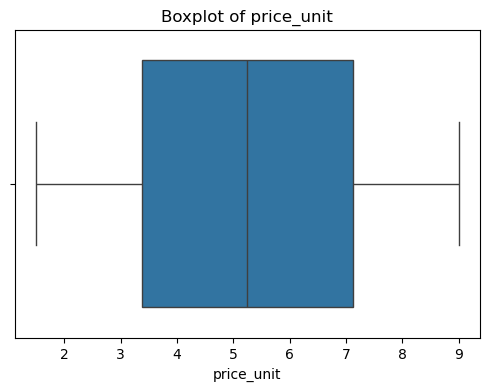

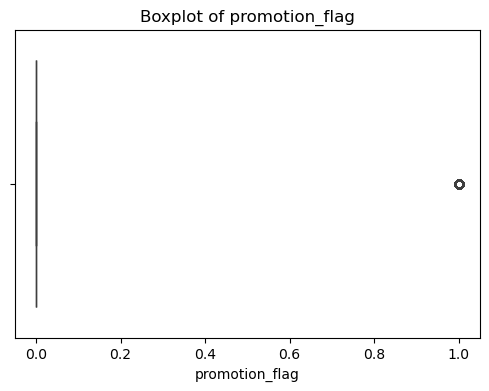

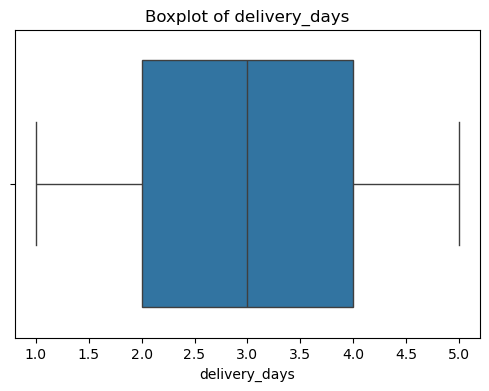

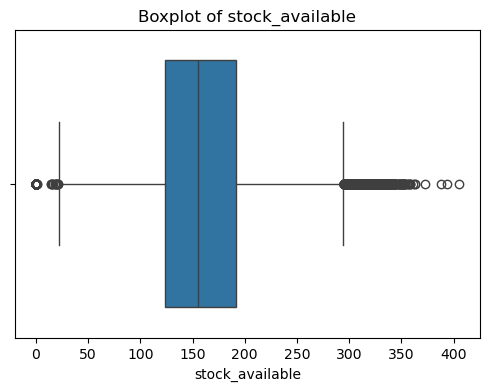

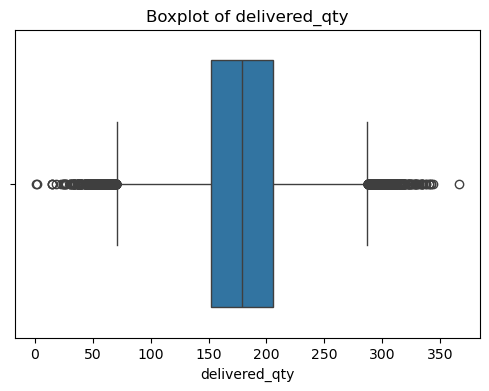

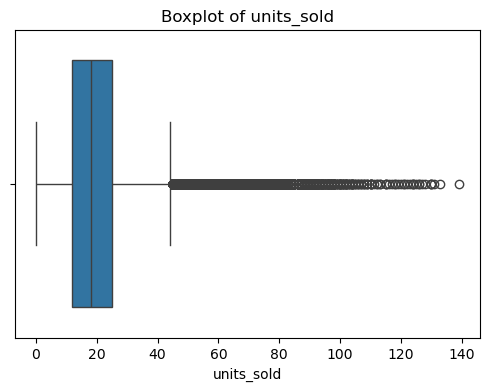

In [183]:
# Outlier prediction
for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [185]:
# Handling outliers using IQR Method
Q1 = df["units_sold"].quantile(0.25)
Q3 = df["units_sold"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df["units_sold"] >= lower) & (df["units_sold"] <= upper)]

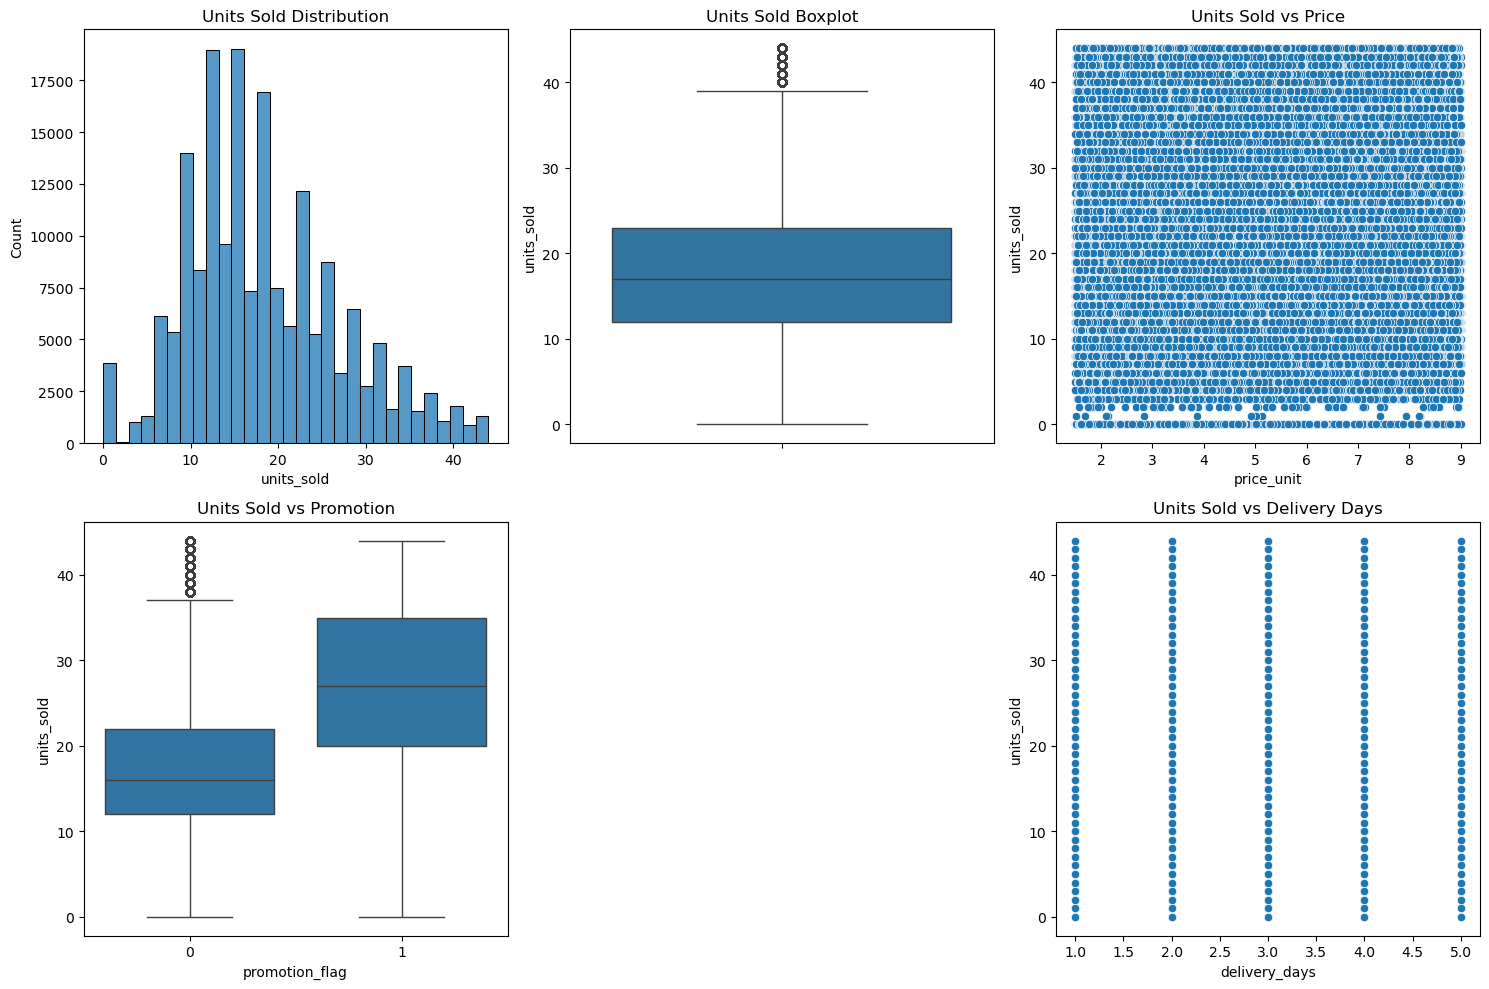

In [187]:
plt.figure(figsize=(15,10))

# 1. Distribution of target
plt.subplot(2,3,1)
sns.histplot(df['units_sold'], bins=30)
plt.title('Units Sold Distribution')

# 2. Boxplot
plt.subplot(2,3,2)
sns.boxplot(y=df['units_sold'])
plt.title('Units Sold Boxplot')

# 3. Units Sold vs Price
plt.subplot(2,3,3)
sns.scatterplot(x=df['price_unit'], y=df['units_sold'])
plt.title('Units Sold vs Price')

# 4. Units Sold vs Promotion
plt.subplot(2,3,4)
sns.boxplot(x=df['promotion_flag'], y=df['units_sold'])
plt.title('Units Sold vs Promotion')

# 6. Units Sold vs Delivery
plt.subplot(2,3,6)
sns.scatterplot(x=df['delivery_days'], y=df['units_sold'])
plt.title('Units Sold vs Delivery Days')

plt.tight_layout()
plt.show()

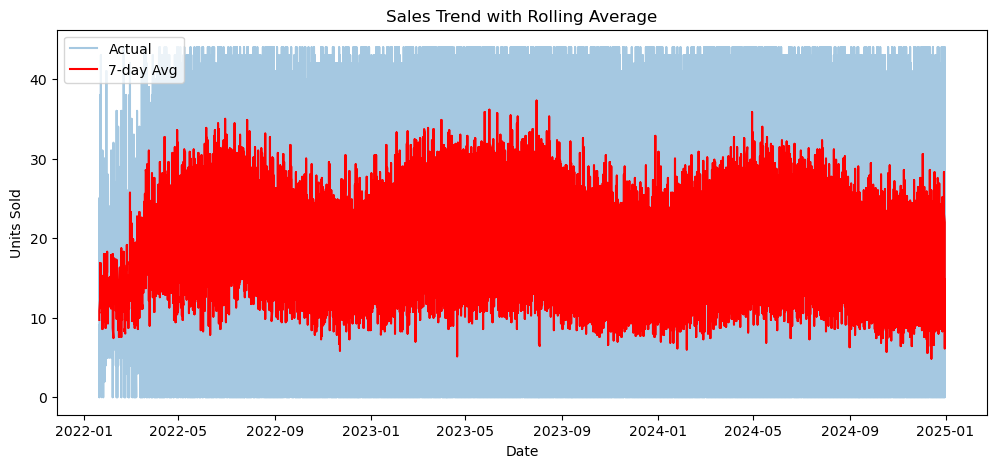

In [189]:
# Smoothed trend over time
df_sorted = df.sort_values('date')

rolling_mean = df_sorted['units_sold'].rolling(window=7).mean()

plt.figure(figsize=(12,5))
plt.plot(df_sorted['date'], df_sorted['units_sold'], alpha=0.4, label='Actual')
plt.plot(df_sorted['date'], rolling_mean, color='red', label='7-day Avg')

plt.title('Sales Trend with Rolling Average')
plt.xlabel('Date')
plt.ylabel('Units Sold')
plt.legend()
plt.show()

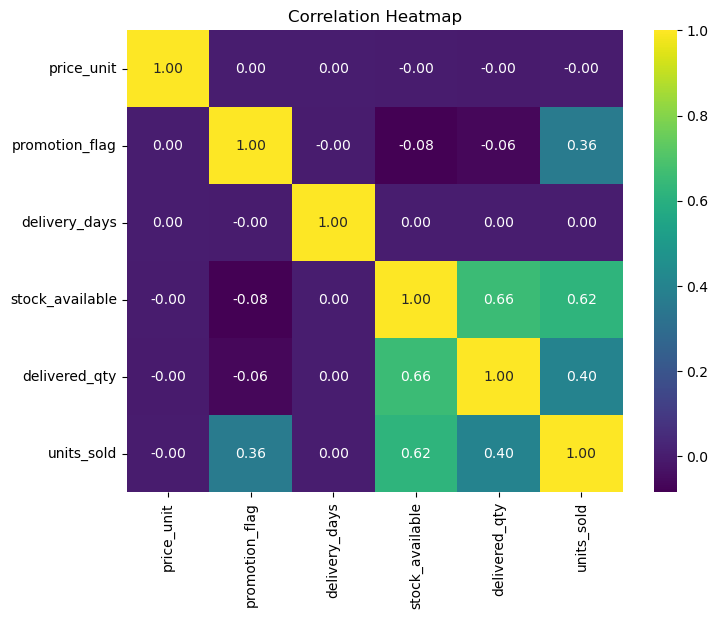

In [191]:
# Correlation chart
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix,
    annot=True,
    cmap="viridis",
    fmt=".2f")

plt.title("Correlation Heatmap")
plt.show()

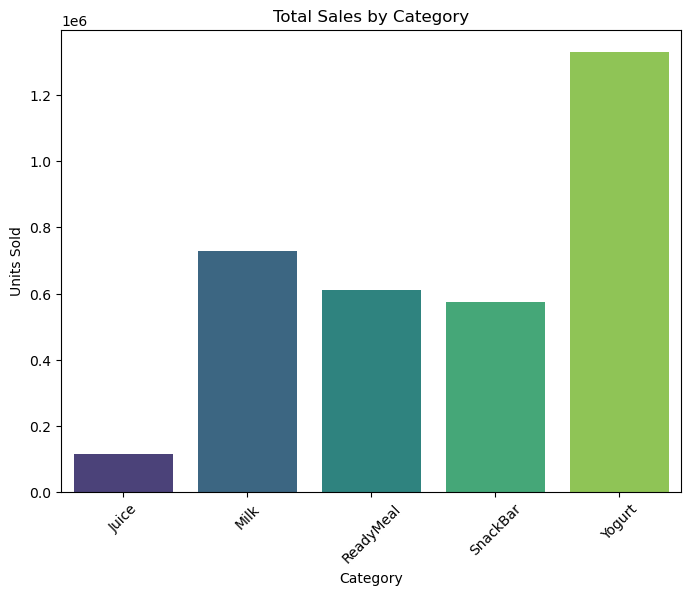

In [192]:
# Aggregate sales by category only
category_sales = df.groupby("category")["units_sold"].sum().reset_index()

plt.figure(figsize=(8,6))

sns.barplot(
    data=category_sales,
    x="category",
    y="units_sold",
    palette="viridis"
)

plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Units Sold")
plt.xticks(rotation=45)

plt.show()

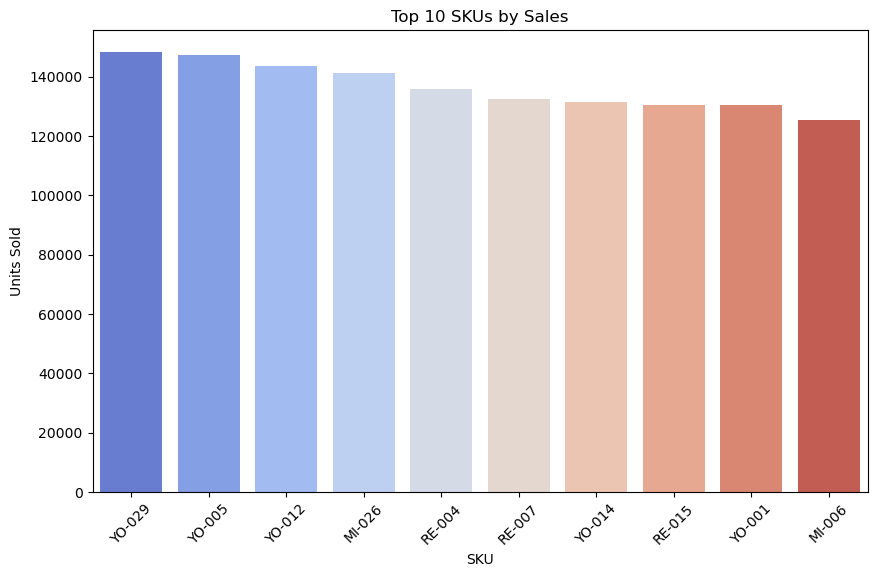

In [194]:
# Top 10 SKUs by sales
sku_sales = df.groupby("sku")["units_sold"].sum().reset_index()
top_sku = sku_sales.sort_values(by="units_sold", ascending=False).head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_sku,
    x="sku",
    y="units_sold",
    palette="coolwarm"
)

plt.title("Top 10 SKUs by Sales")
plt.xlabel("SKU")
plt.ylabel("Units Sold")
plt.xticks(rotation=45)
plt.show()

# 2. Business Analysis

In [198]:
# 3.1 Business overview
print(f"Date range               : {df['date'].min().date()} to {df['date'].max().date()}")
print(f"Number of rows           : {df.shape[0]:,}")
print(f"Number of unique SKUs    : {df['sku'].nunique():,}")
print(f"Number of categories     : {df['category'].nunique():,}")
print(f"Total units sold         : {df['units_sold'].sum():,.0f}")
print(f"Average units sold       : {df['units_sold'].mean():.2f}")
print(f"Median units sold        : {df['units_sold'].median():.2f}")
print(f"Promotion rate           : {df['promotion_flag'].mean() * 100:.2f}%")

Date range               : 2022-01-21 to 2024-12-31
Number of rows           : 183,047
Number of unique SKUs    : 30
Number of categories     : 5
Total units sold         : 3,359,370
Average units sold       : 18.35
Median units sold        : 17.00
Promotion rate           : 12.03%


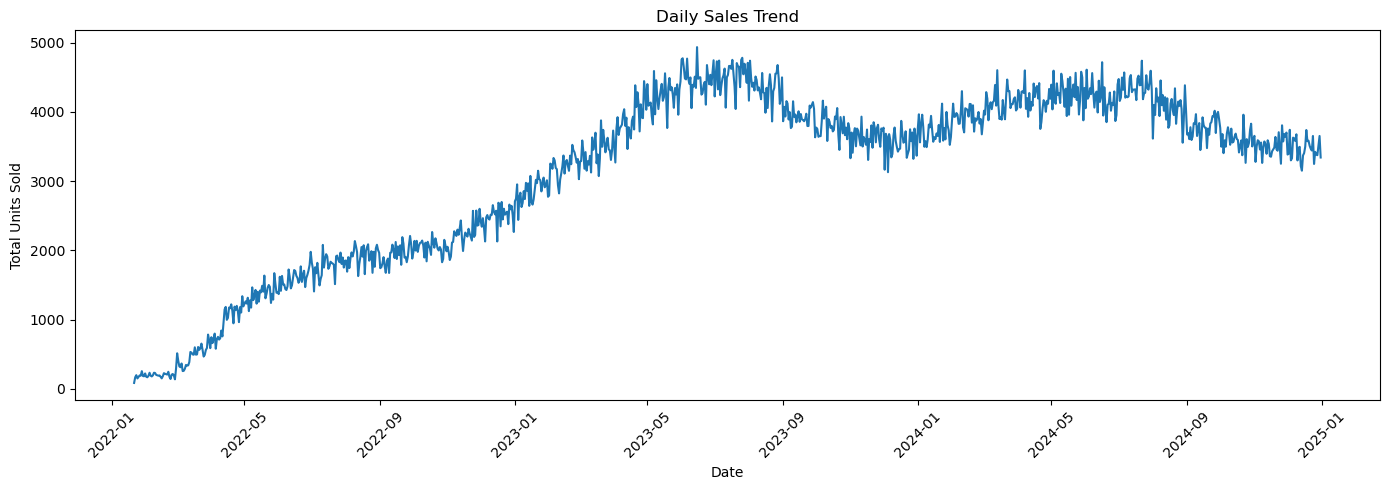

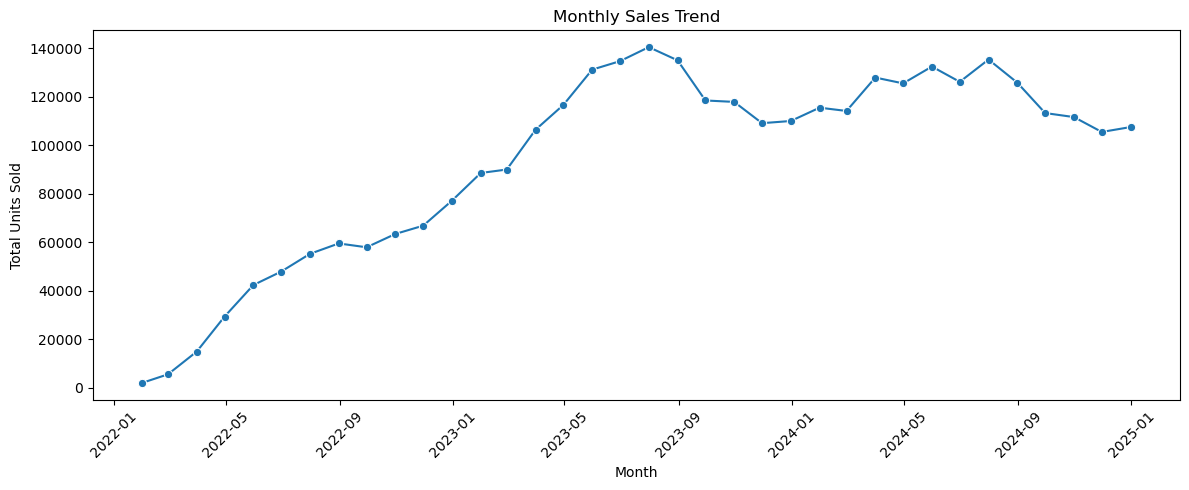

Monthly Sales Summary:


,date,units_sold
31,2024-08-31,125730
32,2024-09-30,113211
33,2024-10-31,111556
34,2024-11-30,105420
35,2024-12-31,107439


In [200]:
# 3.2 Trend Analysis
# Question: How does demand change over time?

daily_sales = df.groupby('date', as_index=False)['units_sold'].sum()

plt.figure(figsize=(14, 5))
sns.lineplot(data=daily_sales, x='date', y='units_sold')
plt.title('Daily Sales Trend')
plt.xlabel('Date')
plt.ylabel('Total Units Sold')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

monthly_sales = (df.set_index('date').resample('ME')['units_sold'].sum().reset_index())

plt.figure(figsize=(12, 5))
sns.lineplot(data=monthly_sales, x='date', y='units_sold', marker='o')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Units Sold')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Monthly Sales Summary:")
display(monthly_sales.tail())

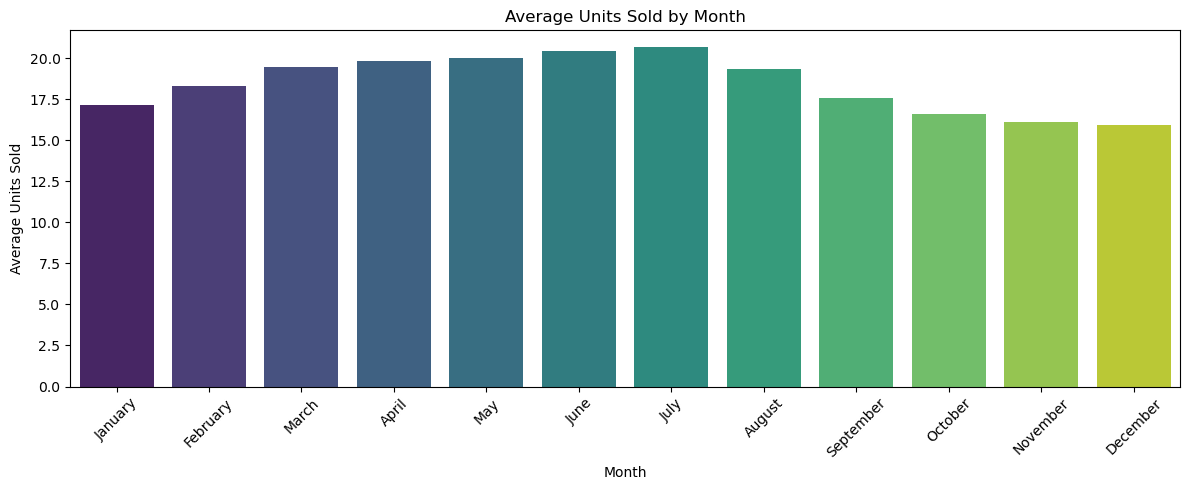

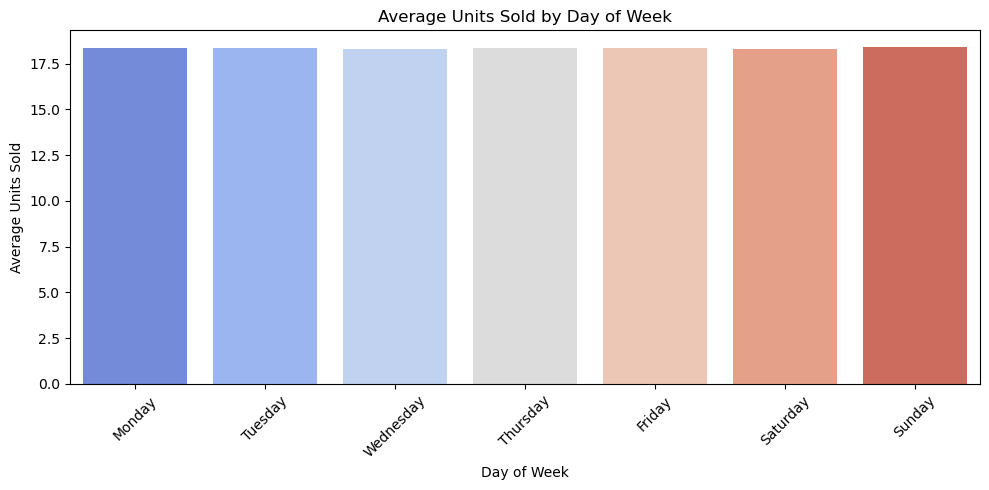

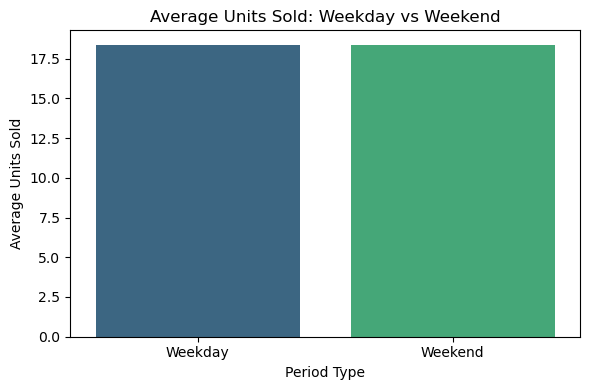

Seasonality Summary:
Top month by average sales:


,month,month_name,units_sold
6,7,July,20.654951


Top day by average sales:


,day_name,units_sold
3,Sunday,18.403576


In [202]:
# 3.3 Seasonality Analysis
# Question: Are there recurring weekly/monthly demand patterns?
df['month'] = df['date'].dt.month
df['month_name'] = df['date'].dt.month_name()
df['day_of_week'] = df['date'].dt.dayofweek
df['day_name'] = df['date'].dt.day_name()
df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)

# Monthly seasonality
monthly_pattern = (
    df.groupby(['month', 'month_name'], as_index=False)['units_sold']
      .mean()
      .sort_values('month'))

plt.figure(figsize=(12, 5))
sns.barplot(data=monthly_pattern, x='month_name', y='units_sold', palette="viridis")
plt.title('Average Units Sold by Month')
plt.xlabel('Month')
plt.ylabel('Average Units Sold')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Weekly seasonality
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

weekly_pattern = (
    df.groupby('day_name', as_index=False)['units_sold']
      .mean()
)

weekly_pattern['day_name'] = pd.Categorical(
    weekly_pattern['day_name'],
    categories=weekday_order,
    ordered=True
)

weekly_pattern = weekly_pattern.sort_values('day_name')

plt.figure(figsize=(10, 5))
sns.barplot(data=weekly_pattern, x='day_name', y='units_sold', palette='coolwarm')
plt.title('Average Units Sold by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Average Units Sold')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Weekday vs Weekend comparison
weekend_summary = df.groupby('is_weekend', as_index=False)['units_sold'].mean()
weekend_summary['period_type'] = weekend_summary['is_weekend'].map({0: 'Weekday', 1: 'Weekend'})

plt.figure(figsize=(6, 4))
sns.barplot(data=weekend_summary, x='period_type', y='units_sold', palette="viridis")
plt.title('Average Units Sold: Weekday vs Weekend')
plt.xlabel('Period Type')
plt.ylabel('Average Units Sold')
plt.tight_layout()
plt.show()

print("Seasonality Summary:")
print("Top month by average sales:")
display(monthly_pattern.sort_values('units_sold', ascending=False).head(1))

print("Top day by average sales:")
display(weekly_pattern.sort_values('units_sold', ascending=False).head(1))


## 2.1 Promotion status analysis

In [205]:
# Summary statistics
promo_summary = df.groupby('promotion_flag', as_index=False).agg(
    avg_units_sold=('units_sold', 'mean'),
    total_units_sold=('units_sold', 'sum'),
    observations=('units_sold', 'count')
)

print("Promotion Summary:")
display(promo_summary)

Promotion Summary:


,promotion_flag,avg_units_sold,total_units_sold,observations
0,0,17.177188,2765888,161021
1,1,26.944611,593482,22026


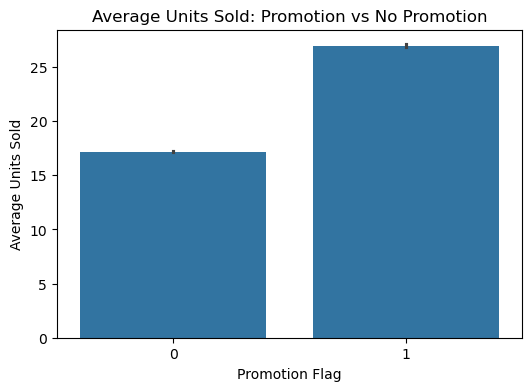

In [207]:
# Average sales comparision
plt.figure(figsize=(6,4))
sns.barplot(data=df,x='promotion_flag',y='units_sold')
plt.title('Average Units Sold: Promotion vs No Promotion')
plt.xlabel('Promotion Flag')
plt.ylabel('Average Units Sold')
plt.show()

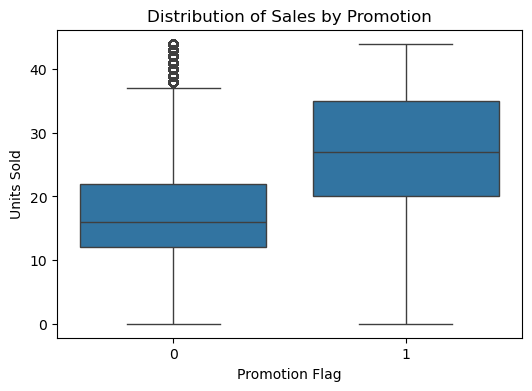

In [209]:
# Distribution comparision
plt.figure(figsize=(6,4))
sns.boxplot(data=df,x='promotion_flag',y='units_sold')
plt.title('Distribution of Sales by Promotion')
plt.xlabel('Promotion Flag')
plt.ylabel('Units Sold')
plt.show()

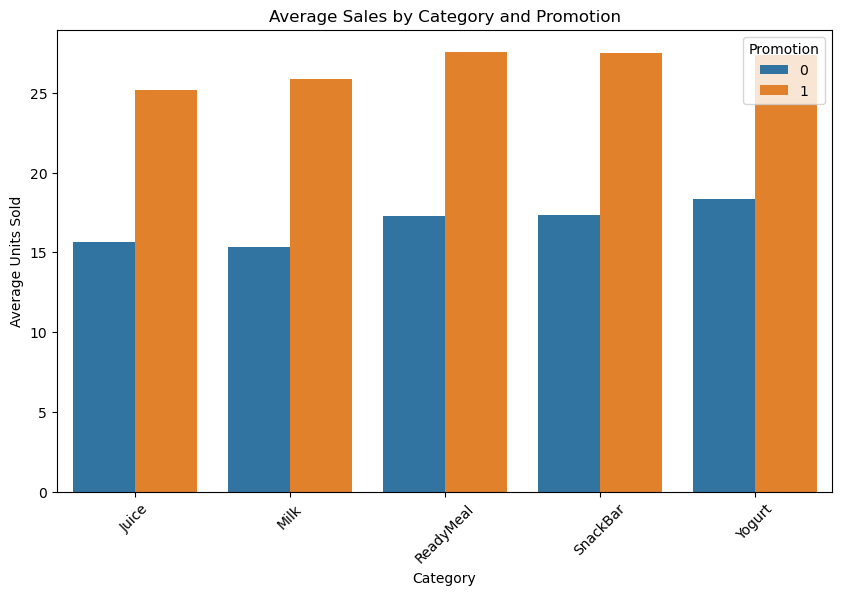

In [211]:
# Category-Level promotion impact
category_promo = df.groupby(['category', 'promotion_flag'])['units_sold'].mean().reset_index()

plt.figure(figsize=(10,6))

sns.barplot(
    data=category_promo,
    x='category',
    y='units_sold',
    hue='promotion_flag'
)

plt.title('Average Sales by Category and Promotion')
plt.xlabel('Category')
plt.ylabel('Average Units Sold')
plt.xticks(rotation=45)

plt.legend(title='Promotion')

plt.show()

In [213]:
# Percentage lift
promo_mean = df[df['promotion_flag'] == 1]['units_sold'].mean()
no_promo_mean = df[df['promotion_flag'] == 0]['units_sold'].mean()

lift = ((promo_mean - no_promo_mean) / no_promo_mean) * 100

print(f"Promotion Lift: {lift:.2f}%")

Promotion Lift: 56.86%


## A/B testing
Null Hypothesis (H₀):
There is no difference in average sales between promotion and non-promotion periods.
                   
                   𝜇𝑝𝑟𝑜𝑚𝑜= 𝜇𝑛𝑜𝑛−𝑝𝑟𝑜𝑚𝑜

Alternative Hypothesis (H₁):
Promotions increase sales.
                    
                   𝜇𝑝𝑟𝑜𝑚𝑜>𝜇𝑛𝑜𝑛−𝑝𝑟𝑜𝑚𝑜	​


In [216]:
# Split into promotion and non-promotion groups using units_sold
# Step 1: Split groups
control_group = df[df['promotion_flag'] == 0]['units_sold']
treatment_group = df[df['promotion_flag'] == 1]['units_sold']

# Step 2: Basic statistics
control_n = len(control_group)
treatment_n = len(treatment_group)

control_mean = control_group.mean()
treatment_mean = treatment_group.mean()

control_std = control_group.std()
treatment_std = treatment_group.std()

# Step 3: Difference and lift
mean_diff = treatment_mean - control_mean
pct_lift = (mean_diff / control_mean) * 100

In [218]:
# Step 4: Print results
print("A/B Testing Summary")

print("Control (No Promotion):")
print("Sample Size:", control_n)
print("Average Sales:", round(control_mean, 2))
print("Std Dev:", round(control_std, 2))

print("Treatment (Promotion):")
print("Sample Size:", treatment_n)
print("Average Sales:", round(treatment_mean, 2))
print("Std Dev:", round(treatment_std, 2))

print("Difference in Sales:", round(mean_diff, 2))
print("Percentage Lift:", round(pct_lift, 2), "%")


A/B Testing Summary
Control (No Promotion):
Sample Size: 161021
Average Sales: 17.18
Std Dev: 7.92
Treatment (Promotion):
Sample Size: 22026
Average Sales: 26.94
Std Dev: 9.86
Difference in Sales: 9.77
Percentage Lift: 56.86 %


In [220]:
# Statistical test - Welch’s t-test

In [222]:
# Welch's t-test
t_stat, p_value = ttest_ind(treatment_group, control_group, equal_var=False)

print(f"T-statistic: {t_stat:.2f}")
print(f"P-value: {p_value:.2f}")
print(f"Mean Difference (Treatment - Control): {mean_diff:.2f}")
print(f"Percentage Lift from Promotion: {pct_lift:.2f}%")

alpha = 0.05
if p_value < alpha:
    print("Result: Promotions have a statistically significant effect on sales.")
else:
    print("Result: No statistically significant promotion effect was detected.")

T-statistic: 140.94
P-value: 0.00
Mean Difference (Treatment - Control): 9.77
Percentage Lift from Promotion: 56.86%
Result: Promotions have a statistically significant effect on sales.


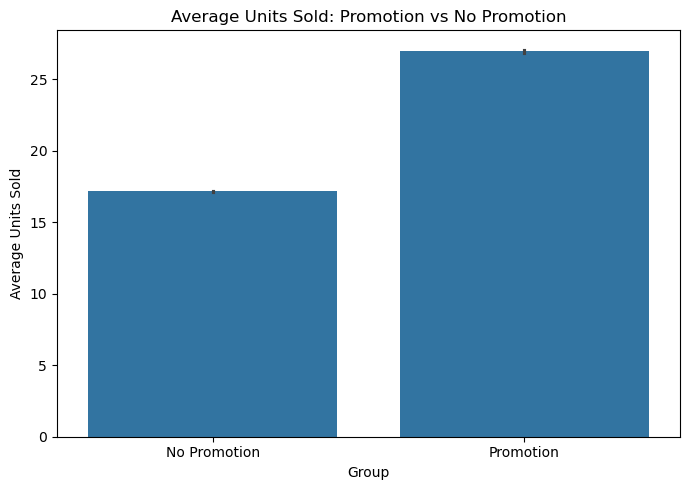

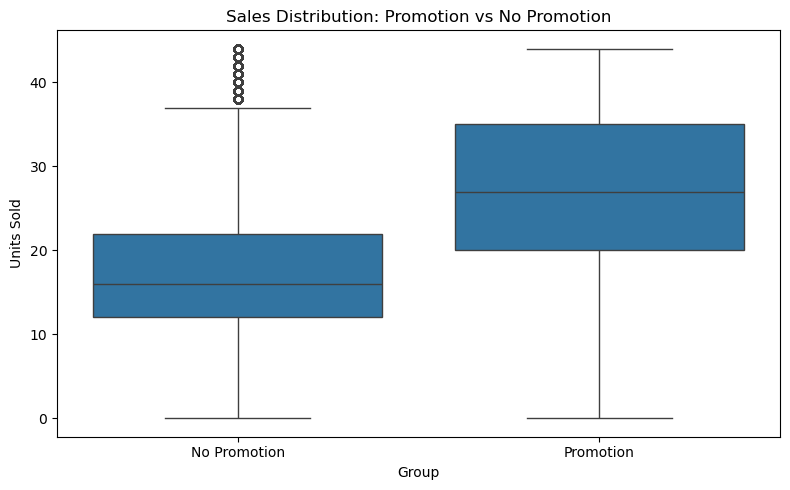

In [224]:
# Create plotting dataframe
ab_plot_df = df[df['promotion_flag'].isin([0, 1])].copy()
ab_plot_df['promotion_group'] = ab_plot_df['promotion_flag'].map({0: 'No Promotion', 1: 'Promotion'})

# Bar plot (average sales)
plt.figure(figsize=(7, 5))
sns.barplot(data=ab_plot_df, x='promotion_group', y='units_sold', errorbar=('ci', 95))
plt.title('Average Units Sold: Promotion vs No Promotion')
plt.xlabel('Group')
plt.ylabel('Average Units Sold')
plt.tight_layout()
plt.show()

# Box plot (distribution)
plt.figure(figsize=(8, 5))
sns.boxplot(data=ab_plot_df, x='promotion_group', y='units_sold')
plt.title('Sales Distribution: Promotion vs No Promotion')
plt.xlabel('Group')
plt.ylabel('Units Sold')
plt.tight_layout()
plt.show()

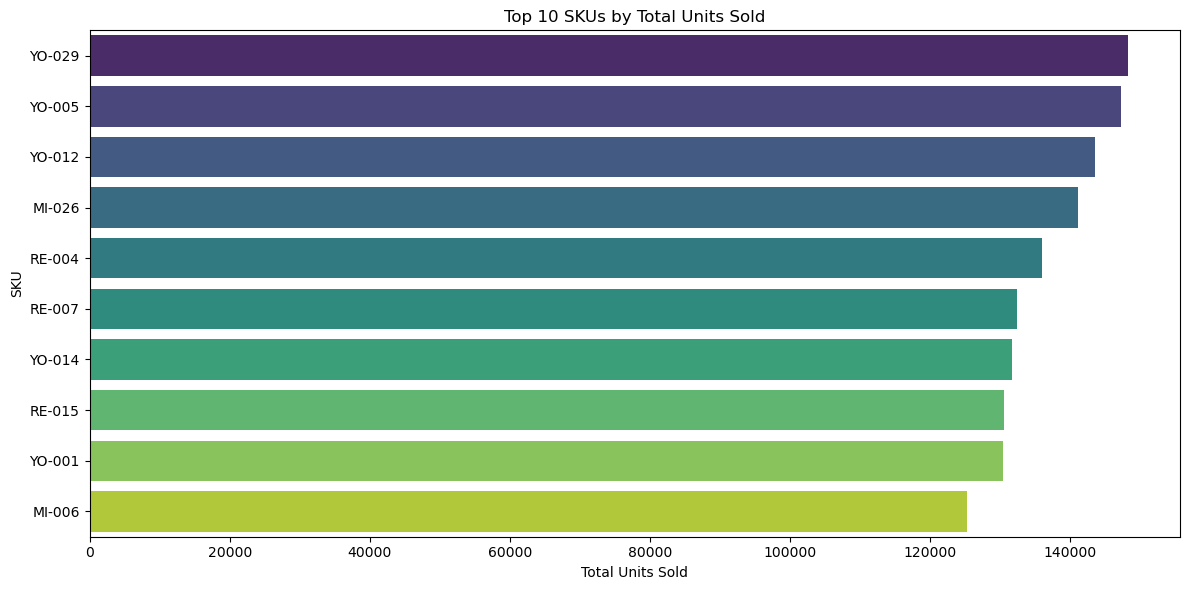

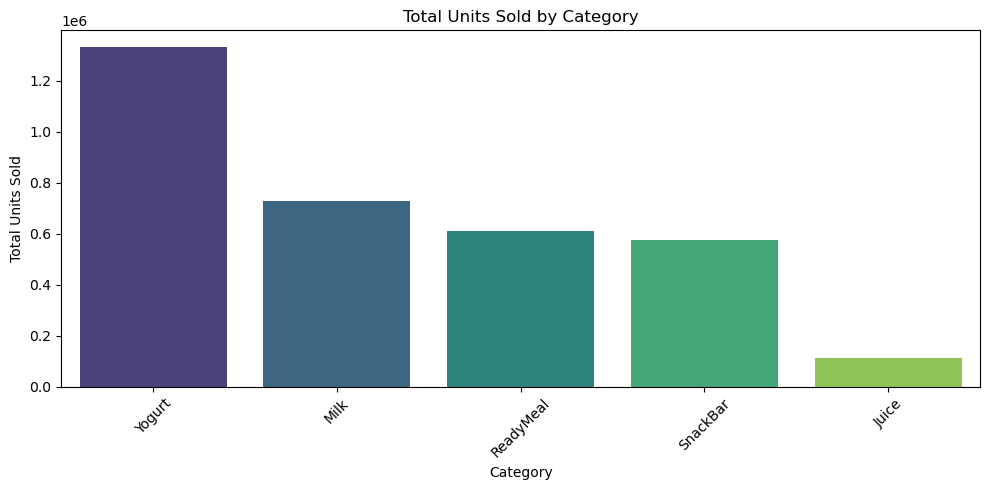

Top 10 SKUs:


,sku,units_sold
29,YO-029,148267
21,YO-005,147238
23,YO-012,143577
7,MI-026,141095
8,RE-004,135917
9,RE-007,132385
24,YO-014,131642
10,RE-015,130502
19,YO-001,130478
2,MI-006,125310


Category Sales Summary:


,category,units_sold
4,Yogurt,1331346
1,Milk,727963
2,ReadyMeal,610818
3,SnackBar,575216
0,Juice,114027


In [226]:
# 3.6 Product Performance Analysis
# Question: Which products and categories drive demand?

top_skus = (
    df.groupby('sku', as_index=False)['units_sold']
      .sum()
      .sort_values('units_sold', ascending=False)
      .head(10)
)

plt.figure(figsize=(12, 6))
sns.barplot(data=top_skus, x='units_sold', y='sku', palette="viridis")
plt.title('Top 10 SKUs by Total Units Sold')
plt.xlabel('Total Units Sold')
plt.ylabel('SKU')
plt.tight_layout()
plt.show()

category_sales = (
    df.groupby('category', as_index=False)['units_sold']
      .sum()
      .sort_values('units_sold', ascending=False)
)

plt.figure(figsize=(10, 5))
sns.barplot(data=category_sales, x='category', y='units_sold', palette="viridis")
plt.title('Total Units Sold by Category')
plt.xlabel('Category')
plt.ylabel('Total Units Sold')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Top 10 SKUs:")
display(top_skus)

print("Category Sales Summary:")
display(category_sales)

## 2.2 Inventory analysis

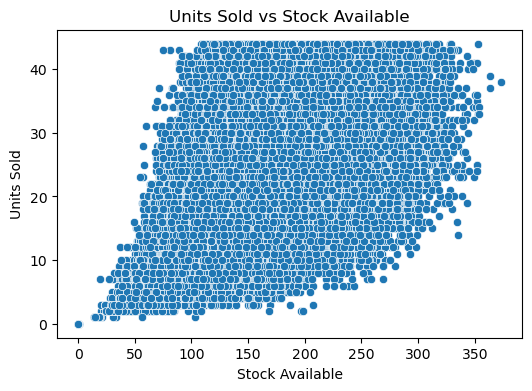

In [229]:
# Unit sold vs stock available
plt.figure(figsize=(6,4))

sns.scatterplot(
    data=df,
    x='stock_available',
    y='units_sold'
)

plt.title('Units Sold vs Stock Available')
plt.xlabel('Stock Available')
plt.ylabel('Units Sold')

plt.show()

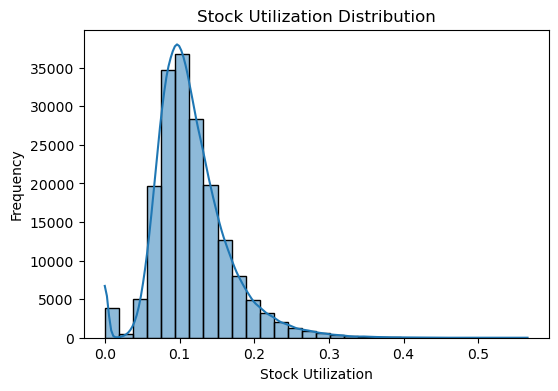

In [231]:
# Stock utilization ratio
df['stock_utilization'] = df['units_sold'] / (df['stock_available'] + 1)

plt.figure(figsize=(6,4))
sns.histplot(df['stock_utilization'], bins=30, kde=True)
plt.title('Stock Utilization Distribution')
plt.xlabel('Stock Utilization')
plt.ylabel('Frequency')
plt.show()

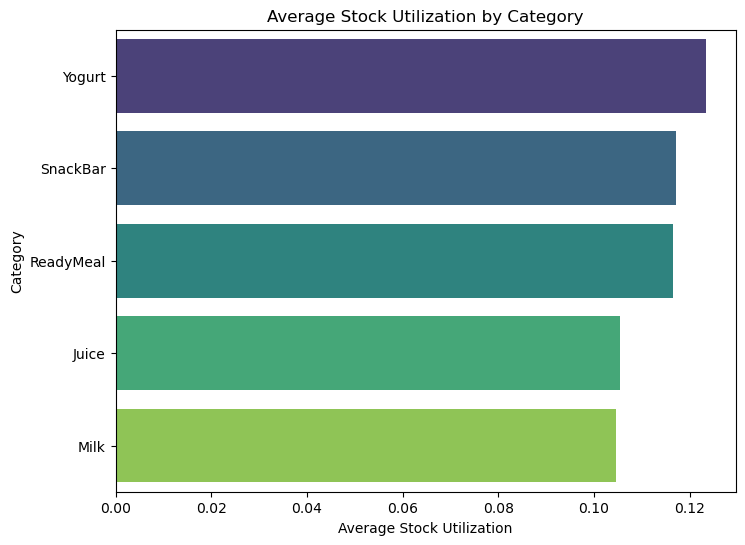

In [233]:
# Average stock utilization by category
category_utilization = df.groupby("category")["stock_utilization"].mean().sort_values(ascending=False)

plt.figure(figsize=(8,6))
sns.barplot(x=category_utilization.values, 
            y=category_utilization.index, 
            palette="viridis")

plt.title("Average Stock Utilization by Category")
plt.xlabel("Average Stock Utilization")
plt.ylabel("Category")
plt.show()

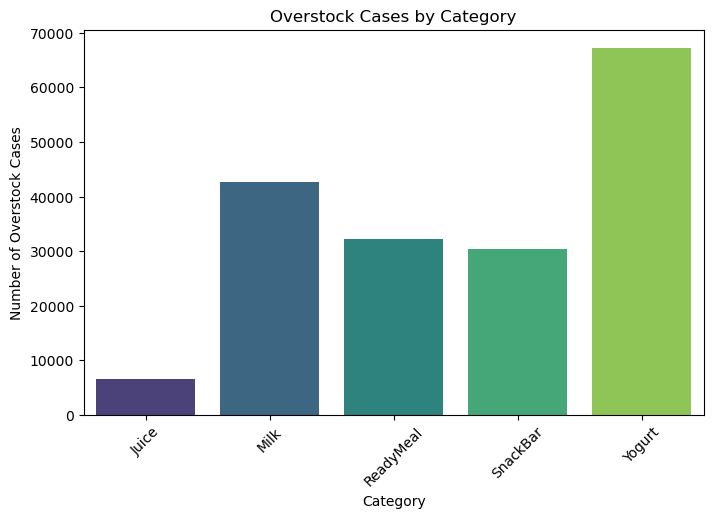

In [235]:
# Overstock detection
overstock = df[df['stock_available'] > df['units_sold'] * 2]
overstock_by_category = overstock.groupby('category').size().reset_index(name='overstock_count')
overstock_by_category


plt.figure(figsize=(8,5))
sns.barplot(
    data=overstock_by_category,
    x='category',
    y='overstock_count',
    palette="viridis"
)
plt.title('Overstock Cases by Category')
plt.xlabel('Category')
plt.ylabel('Number of Overstock Cases')
plt.xticks(rotation=45)
plt.show()

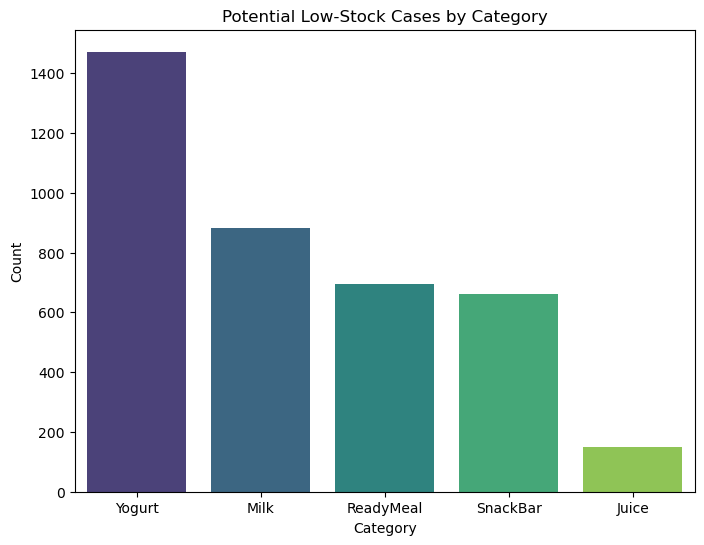

In [237]:
# Low-stock risk (early warning)
low_stock_df = df[df["units_sold"] >= 0.8 * df["stock_available"]]
low_stock_by_category = low_stock_df.groupby('category').size().reset_index(name='low_stock_count')
low_stock_by_category

# Low-stock risk by category
low_stock_category = low_stock_df["category"].value_counts()
plt.figure(figsize=(8,6))
sns.barplot(x=low_stock_category.index, y=low_stock_category.values, palette="viridis")
plt.title("Potential Low-Stock Cases by Category")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()

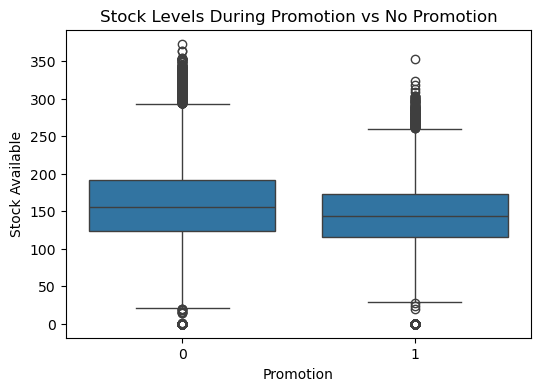

In [239]:
# Stock vs promotion
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='promotion_flag', y='stock_available')
plt.title('Stock Levels During Promotion vs No Promotion')
plt.xlabel('Promotion')
plt.ylabel('Stock Available')
plt.show()

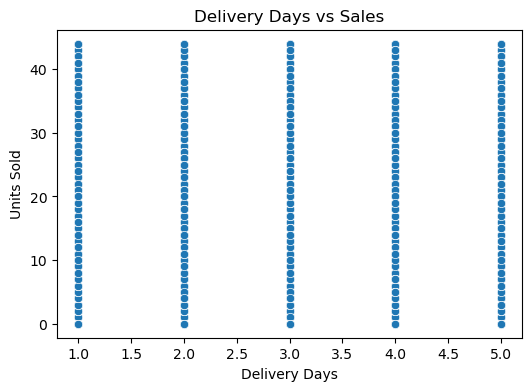

In [241]:
# Delivery impact
plt.figure(figsize=(6,4))
sns.scatterplot(data=df, x='delivery_days', y='units_sold')
plt.title('Delivery Days vs Sales')
plt.xlabel('Delivery Days')
plt.ylabel('Units Sold')
plt.show()

In [242]:
# Inventory summary table by category
inventory_summary = df.groupby("category")[["stock_available", "units_sold", "delivered_qty", "delivery_days", "stock_utilization"]].mean().round(2)
inventory_summary

,stock_available,units_sold,delivered_qty,delivery_days,stock_utilization
category,,,,,
Juice,156.43,16.86,178.53,3.03,0.11
Milk,156.23,16.70,178.38,3.00,0.10
ReadyMeal,155.71,18.51,178.18,3.00,0.12
SnackBar,155.56,18.55,178.22,3.01,0.12
Yogurt,154.60,19.39,177.71,3.01,0.12


# 3. Feature Engineering

In [246]:
df.columns.tolist()

['date',
 'sku',
 'brand',
 'segment',
 'category',
 'channel',
 'region',
 'pack_type',
 'price_unit',
 'promotion_flag',
 'delivery_days',
 'stock_available',
 'delivered_qty',
 'units_sold',
 'month',
 'month_name',
 'day_of_week',
 'day_name',
 'is_weekend',
 'stock_utilization']

In [248]:
# Aggregate duplicates properly
df = (
    df
    .groupby(['sku', 'date', 'region', 'channel'], as_index=False)
    .agg({
        'brand': 'first',
        'segment': 'first',
        'category': 'first',
        'pack_type': 'first',
        'price_unit': 'mean',
        'promotion_flag': 'max',
        'delivery_days': 'mean',
        'stock_available': 'mean',
        'delivered_qty': 'sum',
        'units_sold': 'sum'
    })
)

duplicate_count_after = df.duplicated(subset=['sku', 'date', 'region', 'channel']).sum()
print("Duplicate rows AFTER fix:", duplicate_count_after)

Duplicate rows AFTER fix: 0


In [250]:
df.columns.tolist()

['sku',
 'date',
 'region',
 'channel',
 'brand',
 'segment',
 'category',
 'pack_type',
 'price_unit',
 'promotion_flag',
 'delivery_days',
 'stock_available',
 'delivered_qty',
 'units_sold']

In [252]:
# Create a clean working copy from raw data
df_fe = df.copy()

# Sort datav-very important for time-series (ensures correct lag calculation)
df_fe = df_fe.sort_values(['sku', 'date', 'channel', 'region']).reset_index(drop=True)

# Check the first few rows
df_fe.head()

,sku,date,region,channel,brand,segment,category,pack_type,price_unit,promotion_flag,delivery_days,stock_available,delivered_qty,units_sold
0,JU-021,2022-07-11,PL-South,Discount,JuBrand3,Juice-Seg3,Juice,Carton,6.28,0,5.0,173.0,236,31
1,JU-021,2022-07-11,PL-Central,E-commerce,JuBrand3,Juice-Seg3,Juice,Carton,1.96,0,5.0,192.0,185,16
2,JU-021,2022-07-11,PL-South,E-commerce,JuBrand3,Juice-Seg3,Juice,Single,5.93,0,1.0,98.0,104,12
3,JU-021,2022-07-11,PL-Central,Retail,JuBrand3,Juice-Seg3,Juice,Multipack,8.39,0,3.0,191.0,185,27
4,JU-021,2022-07-11,PL-South,Retail,JuBrand3,Juice-Seg3,Juice,Single,3.62,0,4.0,174.0,155,24


In [254]:
# Additional Calendar Features
df_fe['month'] = df_fe['date'].dt.month
df_fe['day_of_week'] = df_fe['date'].dt.dayofweek
df_fe['is_weekend'] = df_fe['day_of_week'].isin([5, 6]).astype(int)

df_fe['day'] = df_fe['date'].dt.day
df_fe['week_of_year'] = df_fe['date'].dt.isocalendar().week.astype(int)
df_fe['quarter'] = df_fe['date'].dt.quarter
df_fe['is_month_start'] = df_fe['date'].dt.is_month_start.astype(int)
df_fe['is_month_end'] = df_fe['date'].dt.is_month_end.astype(int)

In [256]:
# Lag features (core time-series features) - Past sales help predict future demand
group_cols=['sku', 'region', 'channel']
df_fe['l_1']  = df_fe.groupby(group_cols)['units_sold'].shift(1)
df_fe['l_7']  = df_fe.groupby(group_cols)['units_sold'].shift(7)
df_fe['l_14'] = df_fe.groupby(group_cols)['units_sold'].shift(14)

In [258]:
# 3.4 Cyclical Seasonality Features
df_fe['mo_sin'] = np.sin(2 * np.pi * df_fe['month'] / 12)
df_fe['mo_cos'] = np.cos(2 * np.pi * df_fe['month'] / 12)

df_fe['dow_sin'] = np.sin(2 * np.pi * df_fe['day_of_week'] / 7)
df_fe['dow_cos'] = np.cos(2 * np.pi * df_fe['day_of_week'] / 7)

In [260]:
# Category-level rolling features
# Make sure data is sorted properly
df_fe = df_fe.sort_values(['sku', 'date',  'region', 'channel']).reset_index(drop=True)

# Category rolling mean (7 days)
df_fe['cat_roll_mean_7'] = (
    df_fe.groupby('category')['units_sold']
    .transform(lambda x: x.rolling(7).mean()))

# Category rolling mean (14 days)
df_fe['cat_roll_mean_14'] = (
    df_fe.groupby('category')['units_sold']
    .transform(lambda x: x.rolling(14).mean()))

# Category trend
df_fe['cat_trend_7_14'] = df_fe['cat_roll_mean_7'] - df_fe['cat_roll_mean_14']

# Sort back to main time-series order
df_fe = df_fe.sort_values(['sku', 'region', 'channel', 'date']).reset_index(drop=True)

In [262]:
# Rolling statistics
# Rolling features help capture short-term demand trends and volatility.
# Use shift(1) to ensure only past values are used, preventing leakage.
df_fe['roll_mean_7'] = (df_fe.groupby(group_cols)['units_sold'].transform(lambda x: x.shift(1).rolling(7).mean()))
df_fe['roll_mean_14'] = (df_fe.groupby(group_cols)['units_sold'].transform(lambda x: x.shift(1).rolling(14).mean()))
df_fe['roll_std_7'] = (df_fe.groupby(group_cols)['units_sold'].transform(lambda x: x.shift(1).rolling(7).std()))

In [266]:
# Demand Change / Momentum Features
df_fe['lag_diff_1_7'] = df_fe['l_1'] - df_fe['l_7']
df_fe['trend_7_14'] = df_fe['roll_mean_7'] - df_fe['roll_mean_14']


In [270]:
# Promotions features
# Promotions are often one of the strongest external drivers of FMCG demand.

df_fe['promo_l_1'] = df_fe.groupby(group_cols)['promotion_flag'].shift(1)

df_fe['promo_roll_7'] = df_fe.groupby(group_cols)['promotion_flag'].transform(lambda x: x.shift(1).rolling(7).mean())

df_fe['promo_change'] = df_fe['promotion_flag'] - df_fe['promo_l_1']


In [274]:
# Create price-related features
# Lag price
df_fe['price_l_1'] = df_fe.groupby(group_cols)['price_unit'].shift(1)

# Price change
df_fe['price_change_1'] = df_fe.groupby(group_cols)['price_unit'].diff(1)

# Rolling price
df_fe['price_roll_mean_7'] = (df_fe.groupby(group_cols)['price_unit'].transform(lambda x: x.shift(1).rolling(7).mean()))

In [276]:
# Inventory-related features - useful for connecting demand with stock position
df_fe['stock_l_1'] = df_fe.groupby(group_cols)['stock_available'].shift(1)
df_fe['delivery_l_1'] = df_fe.groupby(group_cols)['delivered_qty'].shift(1)
df_fe['is_stockout'] = (df_fe['stock_available'] == 0).astype(int)

In [278]:
# 4.9 Trend Feature
df_fe['trend'] = (df_fe['date'] - df_fe['date'].min()).dt.days

# 4.10 Interaction Feature
df_fe['promo_price_interaction'] = df_fe['promotion_flag'] * df_fe['price_unit']

df_fe = df_fe.dropna().reset_index(drop=True)
df_fe.shape

(179267, 50)

In [280]:
duplicate_count = df_fe.duplicated(subset=['sku', 'date', 'region', 'channel']).sum()
print("Duplicate (sku, date, region, channel) rows:", duplicate_count)

Duplicate (sku, date, region, channel) rows: 0


# 4. Model development for forecasting and evaluation

In [283]:
# Prepare modelling dataset (LAST 70 DAYS AS TEST SET)
target_col = 'units_sold'

# Use feature-engineered dataset
model_df = df_fe.copy()

# Ensure date is datetime
model_df['date'] = pd.to_datetime(model_df['date'])

# Drop NaNs from lag/rolling features
model_df = model_df.dropna().reset_index(drop=True)

# Sort by date (important for time series)
model_df = model_df.sort_values('date').reset_index(drop=True)

# Define last 70 days as test set
last_date = model_df['date'].max()
test_start_date = last_date - pd.Timedelta(days=69)

# Split dataset
train_df = model_df[model_df['date'] < test_start_date].copy()
test_df = model_df[model_df['date'] >= test_start_date].copy()

# Define X and y
X_train = train_df.drop(columns=[target_col]).copy()
y_train = train_df[target_col].copy()

X_test = test_df.drop(columns=[target_col]).copy()
y_test = test_df[target_col].copy()

# Check split
print("Train date range:", train_df['date'].min(), "to", train_df['date'].max())
print("Test date range :", test_df['date'].min(), "to", test_df['date'].max())
print("Train shape:", X_train.shape, y_train.shape)
print("Test shape :", X_test.shape, y_test.shape)
print("Unique test days:", test_df['date'].nunique())

Train date range: 2022-02-05 00:00:00 to 2024-10-22 00:00:00
Test date range : 2024-10-23 00:00:00 to 2024-12-31 00:00:00
Train shape: (163495, 49) (163495,)
Test shape : (15772, 49) (15772,)
Unique test days: 70


In [285]:
# 3. Define numeric and categorical columns from RAW DataFrame
numeric_cols = X_train.select_dtypes(include=['int64', 'float64', 'int32', 'float32']).columns.tolist()
categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)

Numeric columns: ['price_unit', 'promotion_flag', 'delivery_days', 'stock_available', 'delivered_qty', 'month', 'day_of_week', 'is_weekend', 'day', 'week_of_year', 'quarter', 'is_month_start', 'is_month_end', 'l_1', 'l_7', 'l_14', 'mo_sin', 'mo_cos', 'dow_sin', 'dow_cos', 'cat_roll_mean_7', 'cat_roll_mean_14', 'cat_trend_7_14', 'roll_mean_7', 'roll_mean_14', 'roll_std_7', 'lag_diff_1_7', 'trend_7_14', 'promo_l1', 'promo_roll_7', 'promo_change', 'promo_l_1', 'price_l1', 'price_change_1', 'price_roll_mean_7', 'price_l_1', 'stock_l_1', 'delivery_l_1', 'is_stockout', 'trend', 'promo_price_interaction']
Categorical columns: ['sku', 'region', 'channel', 'brand', 'segment', 'category', 'pack_type']


In [287]:
# 4. Preprocessor with encoder inside pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', SimpleImputer(strategy='median'), numeric_cols),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
        ]), categorical_cols)])

In [289]:
# 5. Full pipeline = preprocessing + model
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LGBMRegressor(random_state=42))])

In [291]:
# 6. Hyperparameter tuning on the FULL pipeline
param_dist = {
    'model__n_estimators': [100, 200, 300, 500],
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__max_depth': [-1, 5, 10, 15],
    'model__num_leaves': [15, 31, 50, 70],
    'model__min_child_samples': [10, 20, 30, 50],
    'model__subsample': [0.8, 0.9, 1.0],
    'model__colsample_bytree': [0.8, 0.9, 1.0]
}

random_search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_dist,
    n_iter=20,
    scoring='neg_root_mean_squared_error',
    cv=3,
    verbose=1,
    n_jobs=-1,
    random_state=42)

random_search.fit(X_train, y_train)

print("Best Parameters:")
print(random_search.best_params_)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.045768 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4974
[LightGBM] [Info] Number of data points in the train set: 163495, number of used features: 48
[LightGBM] [Info] Start training from score 18.678706
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: 

In [299]:
# 7. Final tuned model and predictions
final_model = random_search.best_estimator_
final_pred = final_model.predict(X_test)

In [301]:
# 8. Evaluation function
def evaluate_model(y_true, y_pred, model_name):
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    mae = np.mean(np.abs(y_true - y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / np.where(y_true == 0, 1, y_true))) * 100
    return {'Model': model_name,'RMSE': rmse,'MAE': mae,'MAPE': mape}

In [303]:
# 9. Final tuned model evaluation
final_results = pd.DataFrame([evaluate_model(y_test, final_pred, 'LightGBM Tuned')])
final_results

,Model,RMSE,MAE,MAPE
0,LightGBM Tuned,3.567799,2.66836,19.905848


In [305]:
# 10. Create prediction dataframe
# Keep only columns that exist in test_df

evaluation_df = test_df[['date', 'sku', 'category', 'units_sold']].copy()
evaluation_df['predicted_units_sold'] = final_pred
evaluation_df['error'] = evaluation_df['units_sold'] - evaluation_df['predicted_units_sold']
evaluation_df['absolute_error'] = evaluation_df['error'].abs()

evaluation_df.to_csv('evaluation_predictions.csv', index=False)

evaluation_df.head()

,date,sku,category,units_sold,predicted_units_sold,error,absolute_error
163495,2024-10-23,RE-007,ReadyMeal,36,33.563150,2.436850,2.436850
163496,2024-10-23,YO-029,Yogurt,7,9.611780,-2.611780,2.611780
163497,2024-10-23,YO-012,Yogurt,17,16.797133,0.202867,0.202867
163498,2024-10-23,SN-027,SnackBar,14,13.549436,0.450564,0.450564
163499,2024-10-23,YO-016,Yogurt,22,19.549941,2.450059,2.450059


In [307]:
# 11. SKU-level evaluation
sku_results = []

for sku, group in evaluation_df.groupby('sku'):
    sku_results.append(
        evaluate_model(group['units_sold'], group['predicted_units_sold'], sku)
    )

sku_results_df = pd.DataFrame(sku_results).sort_values(by='RMSE', ascending=False).reset_index(drop=True)
sku_results_df.to_csv('sku_level_metrics.csv', index=False)

sku_results_df.head()


,Model,RMSE,MAE,MAPE
0,RE-015,4.181645,3.195103,20.059956
1,RE-004,4.165755,3.182116,19.362737
2,RE-007,4.021069,3.044082,19.652382
3,RE-017,3.986400,3.031120,17.328138
4,RE-025,3.983494,2.940851,16.805683


In [309]:
# 12. Category-level evaluation
category_results = []

for category, group in evaluation_df.groupby('category'):
    category_results.append(
        evaluate_model(group['units_sold'], group['predicted_units_sold'], category)
    )

category_results_df = pd.DataFrame(category_results).sort_values(by='RMSE').reset_index(drop=True)
category_results_df.to_csv('category_level_metrics.csv', index=False)

category_results_df.head()


,Model,RMSE,MAE,MAPE
0,Juice,2.970011,2.233917,23.224790
1,Milk,3.390673,2.502085,20.670688
2,Yogurt,3.426769,2.576888,20.036599
3,SnackBar,3.680209,2.772280,19.238612
4,ReadyMeal,4.067840,3.077757,18.636510


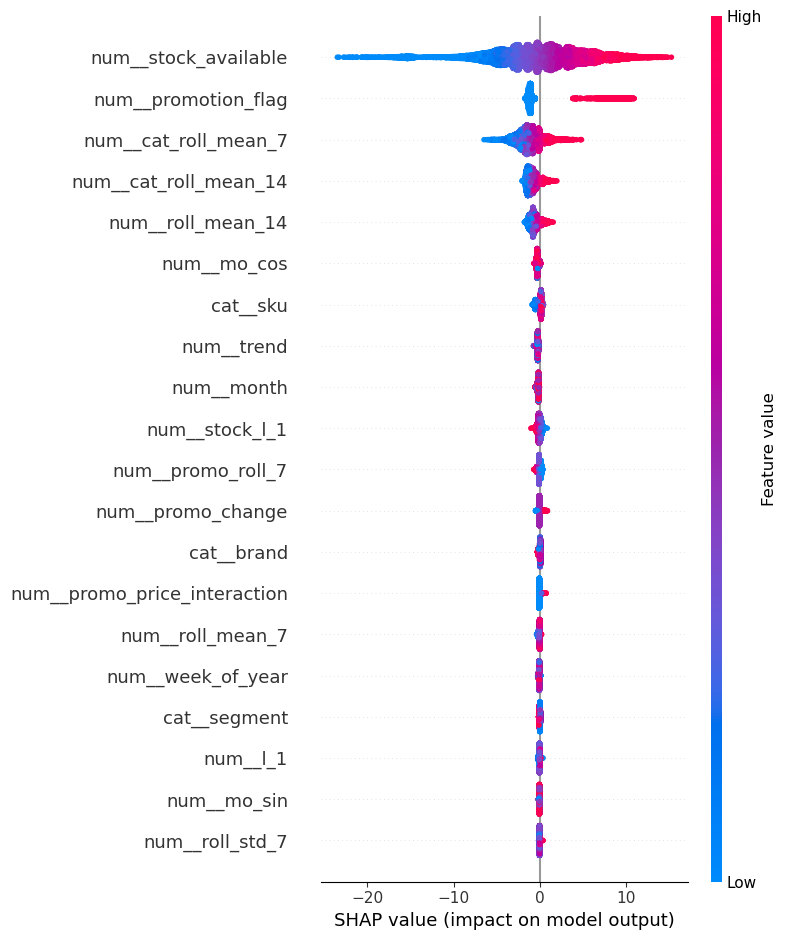

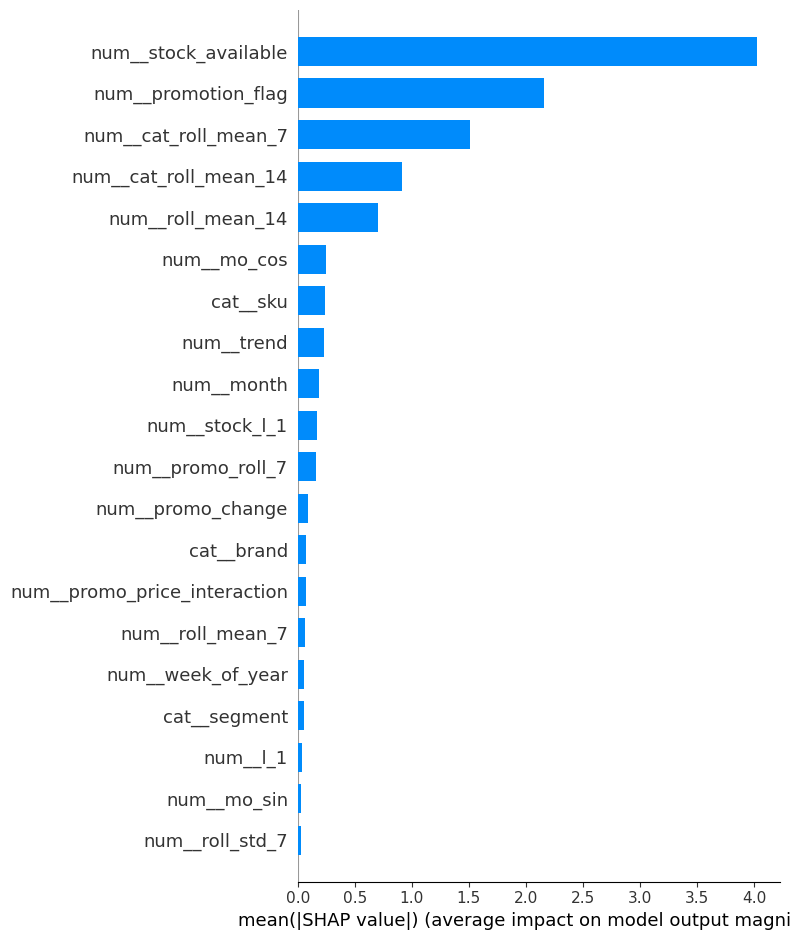

,feature,mean_abs_shap
0,num__stock_available,4.025176
1,num__promotion_flag,2.157294
2,num__cat_roll_mean_7,1.509642
3,num__cat_roll_mean_14,0.914989
4,num__roll_mean_14,0.701982


In [311]:
# 13. SHAP analysis
import shap

X_test_transformed = final_model.named_steps['preprocessor'].transform(X_test)
feature_names = final_model.named_steps['preprocessor'].get_feature_names_out()

lgbm_model = final_model.named_steps['model']
explainer = shap.TreeExplainer(lgbm_model)
shap_values = explainer.shap_values(X_test_transformed)

# Summary plots
shap.summary_plot(shap_values, X_test_transformed, feature_names=feature_names)
shap.summary_plot(shap_values, X_test_transformed, feature_names=feature_names, plot_type='bar')

# SHAP importance dataframe
shap_array = np.array(shap_values)

shap_importance_df = pd.DataFrame({
    'feature': feature_names,
    'mean_abs_shap': np.abs(shap_array).mean(axis=0)
}).sort_values(by='mean_abs_shap', ascending=False).reset_index(drop=True)

shap_importance_df.to_csv('shap_feature_importance.csv', index=False)

shap_importance_df.head()

In [313]:
# Saving essential CSV files
import joblib

# 1. Save model (pipeline)
joblib.dump(final_model, 'final_lightgbm_model.pkl')

# 2. Save dashboard dataset (clean business data)
df.to_csv('processed_fmcg.csv', index=False)

# 3. Save feature-engineered dataset (for forecasting)
df_fe.to_csv('processed_fmcg_engineered.csv', index=False)

# 4. Save prediction results
evaluation_df.to_csv('evaluation_predictions.csv', index=False)

# 5. Save SKU-level metrics
sku_results_df.to_csv('sku_level_metrics.csv', index=False)

# 6. Save Category-level metrics
category_results_df.to_csv('category_level_metrics.csv', index=False)

# 7. Save SHAP feature importance
shap_importance_df.to_csv('shap_feature_importance.csv', index=False)